In [71]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    SimpleRNN,
    LSTM,
    GRU,
    Bidirectional,
    Dense,
    Dropout
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score
)



In [72]:
df = pd.read_csv("../Dataset/df_for_EDA.csv")

In [73]:
df

,Datetime,PJME_MW,Hour,DayOfWeek,Month,Day,Week,Year,IsWeekend,Lag_1,Lag_24,Lag_168,RollingMean_24,RollingMean_168,RollingStd_24
0,1998-12-24 01:00:00,27213.0,1,3,12,24,52,1998,0,28570.0,27669.0,26498.0,29475.375000,30894.589286,2736.646326
1,1998-12-24 02:00:00,25643.0,2,3,12,24,52,1998,0,27213.0,26162.0,25147.0,29453.750000,30897.541667,2765.861628
2,1998-12-24 03:00:00,24907.0,3,3,12,24,52,1998,0,25643.0,25483.0,24574.0,29429.750000,30899.523810,2804.050165
3,1998-12-24 04:00:00,24721.0,4,3,12,24,52,1998,0,24907.0,25045.0,24393.0,29416.250000,30901.476190,2826.766154
4,1998-12-24 05:00:00,25144.0,5,3,12,24,52,1998,0,24721.0,25030.0,24860.0,29421.000000,30903.166667,2819.160745
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145193,2014-03-02 03:00:00,44284.0,3,6,3,2,9,2014,1,44343.0,45787.0,42112.0,40343.500000,41856.327381,2295.270146
145194,2014-03-02 04:00:00,43751.0,4,6,3,2,9,2014,1,44284.0,45209.0,40797.0,40282.750000,41873.910714,2177.148998
145195,2014-03-02 05:00:00,42402.0,5,6,3,2,9,2014,1,43751.0,43663.0,38819.0,40230.208333,41895.238095,2106.081917
145196,2014-03-02 06:00:00,40164.0,6,6,3,2,9,2014,1,42402.0,41581.0,36287.0,40171.166667,41918.315476,2086.336995


In [74]:
df["Datetime"] = pd.to_datetime(df["Datetime"])


df["Hour"] = df["Datetime"].dt.hour

df["Day"] = df["Datetime"].dt.day

df["DayOfWeek"] = df["Datetime"].dt.dayofweek

df["Week"] = df["Datetime"].dt.isocalendar().week.astype(int)

df["Month"] = df["Datetime"].dt.month

df["Year"] = df["Datetime"].dt.year

df["IsWeekend"] = ( df["DayOfWeek"] >= 5 ).astype(int)

# Lag 

df["Lag_1"] = df["PJME_MW"].shift(1)
df["Lag_2"] = df["PJME_MW"].shift(2)
df["Lag_3"] = df["PJME_MW"].shift(3)
df["Lag_6"] = df["PJME_MW"].shift(6)
df["Lag_12"] = df["PJME_MW"].shift(12)
df["Lag_24"] = df["PJME_MW"].shift(24)
df["Lag_48"] = df["PJME_MW"].shift(48)
df["Lag_72"] = df["PJME_MW"].shift(72)
df["Lag_168"] = df["PJME_MW"].shift(168)

# Rolling mean and std

df["RollingMean_24"] = (
    df["PJME_MW"]
    .rolling(24)
    .mean()
)


df["RollingMean_168"] = (
    df["PJME_MW"]
    .rolling(168)
    .mean()
)


df["RollingStd_24"] = (
    df["PJME_MW"]
    .rolling(24)
    .std()
)

In [75]:
df

,Datetime,PJME_MW,Hour,DayOfWeek,Month,Day,Week,Year,IsWeekend,Lag_1,...,Lag_168,RollingMean_24,RollingMean_168,RollingStd_24,Lag_2,Lag_3,Lag_6,Lag_12,Lag_48,Lag_72
0,1998-12-24 01:00:00,27213.0,1,3,12,24,52,1998,0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1998-12-24 02:00:00,25643.0,2,3,12,24,52,1998,0,27213.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1998-12-24 03:00:00,24907.0,3,3,12,24,52,1998,0,25643.0,...,NaN,NaN,NaN,NaN,27213.0,NaN,NaN,NaN,NaN,NaN
3,1998-12-24 04:00:00,24721.0,4,3,12,24,52,1998,0,24907.0,...,NaN,NaN,NaN,NaN,25643.0,27213.0,NaN,NaN,NaN,NaN
4,1998-12-24 05:00:00,25144.0,5,3,12,24,52,1998,0,24721.0,...,NaN,NaN,NaN,NaN,24907.0,25643.0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145193,2014-03-02 03:00:00,44284.0,3,6,3,2,9,2014,1,44343.0,...,42112.0,40343.500000,41856.327381,2295.270146,44147.0,41213.0,38726.0,40154.0,43308.0,45896.0
145194,2014-03-02 04:00:00,43751.0,4,6,3,2,9,2014,1,44284.0,...,40797.0,40282.750000,41873.910714,2177.148998,44343.0,44147.0,38737.0,40309.0,42440.0,45377.0
145195,2014-03-02 05:00:00,42402.0,5,6,3,2,9,2014,1,43751.0,...,38819.0,40230.208333,41895.238095,2106.081917,44284.0,44343.0,39337.0,39884.0,40661.0,44092.0
145196,2014-03-02 06:00:00,40164.0,6,6,3,2,9,2014,1,42402.0,...,36287.0,40171.166667,41918.315476,2086.336995,43751.0,44284.0,41213.0,39544.0,38207.0,42257.0


In [76]:
df = df.dropna().reset_index(drop=True)

In [77]:
df.isna().sum()

Datetime           0
PJME_MW            0
Hour               0
DayOfWeek          0
Month              0
Day                0
Week               0
Year               0
IsWeekend          0
Lag_1              0
Lag_24             0
Lag_168            0
RollingMean_24     0
RollingMean_168    0
RollingStd_24      0
Lag_2              0
Lag_3              0
Lag_6              0
Lag_12             0
Lag_48             0
Lag_72             0
dtype: int64

In [78]:
features = [
    "PJME_MW",
    "Hour",
    "Day",
    "Week",
    "Month",
    "DayOfWeek",
    "IsWeekend",
    "Lag_1",
    "Lag_24",
    "Lag_168",
    "RollingMean_24",
    "RollingMean_168",
    "RollingStd_24",
    "Lag_2",
    "Lag_3",
    "Lag_6",
    "Lag_12",
    "Lag_48",
    "Lag_72"
]

target = "PJME_MW"

X = df[features]
y = df[target]

In [79]:
df = df.sort_values("Datetime").reset_index(drop=True)

print(df["Datetime"].min())
print(df["Datetime"].max())
print(df.shape)

1998-04-01 01:00:00
2015-01-01 00:00:00
(145030, 21)


In [ ]:
test_size = int(len(df) * 0.20)

test_start = len(df) - test_size

X_test = X.iloc[test_start:]
y_test = y.iloc[test_start:]


validation_hours = 60 * 24   

val_start = test_start - validation_hours

X_val = X.iloc[val_start:test_start]
y_val = y.iloc[val_start:test_start]

X_train = X.iloc[:val_start]
y_train = y.iloc[:val_start]

print("X_train:", X_train.shape)
print("X_val  :", X_val.shape)
print("X_test :", X_test.shape)

print("\ny_train:", y_train.shape)
print("y_val  :", y_val.shape)
print("y_test :", y_test.shape)

X_train: (114584, 19)
X_val  : (1440, 19)
X_test : (29006, 19)

y_train: (114584,)
y_val  : (1440,)
y_test : (29006,)


In [114]:
from sklearn.preprocessing import StandardScaler

X_scaler = StandardScaler()

X_train_scaled = X_scaler.fit_transform(X_train)

X_val_scaled = X_scaler.transform(X_val)

X_test_scaled = X_scaler.transform(X_test)

In [ ]:
y_scaler = StandardScaler()

y_train_scaled = y_scaler.fit_transform(
    y_train.values.reshape(-1, 1)
)

y_val_scaled = y_scaler.transform(
    y_val.values.reshape(-1, 1)
)

y_test_scaled = y_scaler.transform(
    y_test.values.reshape(-1, 1)
)

In [96]:
def create_sequences(X, y, sequence_length, forecast_horizon):

    X_sequences = []
    y_sequences = []

    for i in range(
        sequence_length,
        len(X) - forecast_horizon + 1
    ):

        X_sequences.append(
            X[i-sequence_length:i]
        )

        y_sequences.append(
            y[i:i+forecast_horizon]
        )

    return np.array(X_sequences), np.array(y_sequences)

In [97]:
sequence_length = 48
forecast_horizon = 24

In [98]:
X_train_seq, y_train_seq = create_sequences(
    X_train_scaled,
    y_train_scaled,
    sequence_length,
    forecast_horizon
)

X_val_seq, y_val_seq = create_sequences(
    X_val_scaled,
    y_val_scaled,
    sequence_length,
    forecast_horizon
)

X_test_seq, y_test_seq = create_sequences(
    X_test_scaled,
    y_test_scaled,
    sequence_length,
    forecast_horizon
)

In [87]:
print("X_train:", X_train_seq.shape)
print("y_train:", y_train_seq.shape)

print("X_val:", X_val_seq.shape)
print("y_val:", y_val_seq.shape)

print("X_test:", X_test_seq.shape)
print("y_test:", y_test_seq.shape)

X_train: (114513, 48, 19)
y_train: (114513, 24, 1)
X_val: (1369, 48, 19)
y_val: (1369, 24, 1)
X_test: (28935, 48, 19)
y_test: (28935, 24, 1)


In [99]:
best_bilstm_model = tf.keras.models.load_model(
    "../Models/bilstm_model_48_RMS_86.keras"
)

final_model = best_bilstm_model

In [100]:
val_pred_scaled = final_model.predict(
    X_val_seq
)

43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step


In [ ]:
val_pred = y_scaler.inverse_transform(
    val_pred_scaled.reshape(-1, 1)
).reshape(val_pred_scaled.shape)

In [ ]:
y_val_original = y_scaler.inverse_transform(
    y_val_seq.reshape(-1, 1)
).reshape(y_val_seq.shape)

In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

y_true = y_val_original.flatten()
y_pred = val_pred.flatten()

mae = mean_absolute_error(
    y_true,
    y_pred
)

mse = mean_squared_error(
    y_true,
    y_pred
)

rmse = np.sqrt(mse)

mape = np.mean(
    np.abs((y_true - y_pred) / y_true)
) * 100

r2 = r2_score(
    y_true,
    y_pred
)

bias = np.mean(
    y_pred - y_true
)

print("60 Validation Results")
print("------------------")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("MAPE:", mape)
print("R²  :", r2)
print("Bias:", bias)

Validation Results
------------------
MAE : 1095.360548206568
MSE : 1954843.8792847178
RMSE: 1398.1573156425272
MAPE: 4.123614323971101
R²  : 0.861532655908
Bias: 664.0441483766283


In [105]:
print("TRAIN:")
print(df.iloc[:val_start]["Datetime"].min())
print(df.iloc[:val_start]["Datetime"].max())

print("\nVALIDATION:")
print(df.iloc[val_start:test_start]["Datetime"].min())
print(df.iloc[val_start:test_start]["Datetime"].max())

print("\nTEST:")
print(df.iloc[test_start:]["Datetime"].min())
print(df.iloc[test_start:]["Datetime"].max())

TRAIN:
1998-04-01 01:00:00
2011-05-12 12:00:00

VALIDATION:
2011-05-12 13:00:00
2011-07-11 12:00:00

TEST:
2011-07-11 13:00:00
2015-01-01 00:00:00


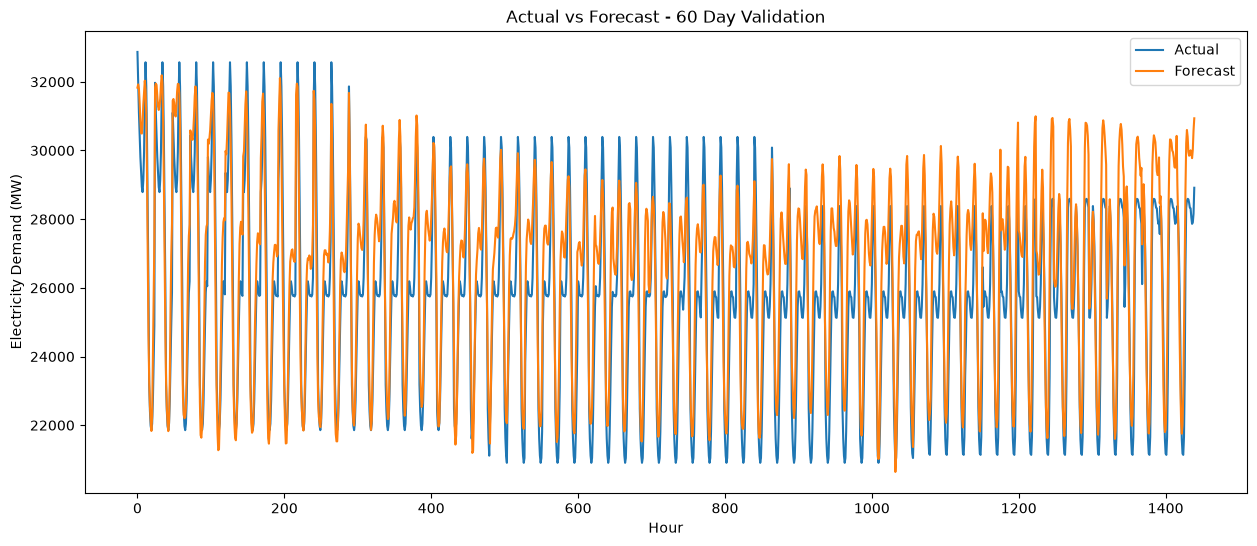

In [125]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 6))

plt.plot(
    y_true[:24 * 60],
    label="Actual"
)

plt.plot(
    y_pred[:24 * 60],
    label="Forecast"
)

plt.title("Actual vs Forecast - 60 Day Validation")
plt.xlabel("Hour")
plt.ylabel("Electricity Demand (MW)")
plt.legend()
plt.show()

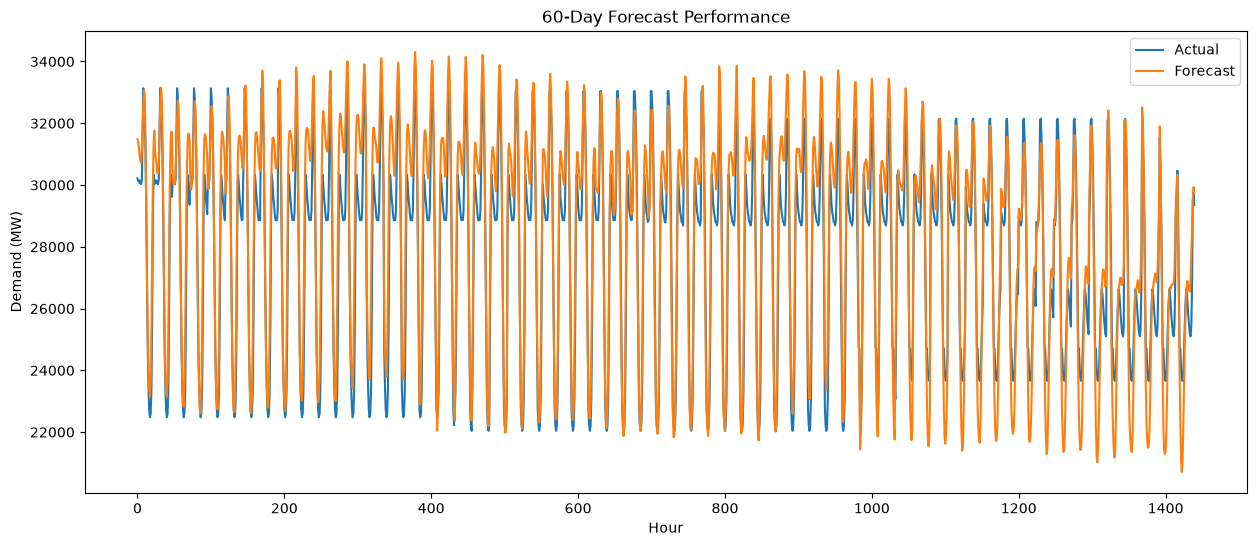

In [108]:
hours_60 = 60 * 24

plt.figure(figsize=(15, 6))

plt.plot(
    y_true[:hours_60],
    label="Actual"
)

plt.plot(
    y_pred[:hours_60],
    label="Forecast"
)

plt.title("60-Day Forecast Performance")
plt.xlabel("Hour")
plt.ylabel("Demand (MW)")
plt.legend()

plt.show()

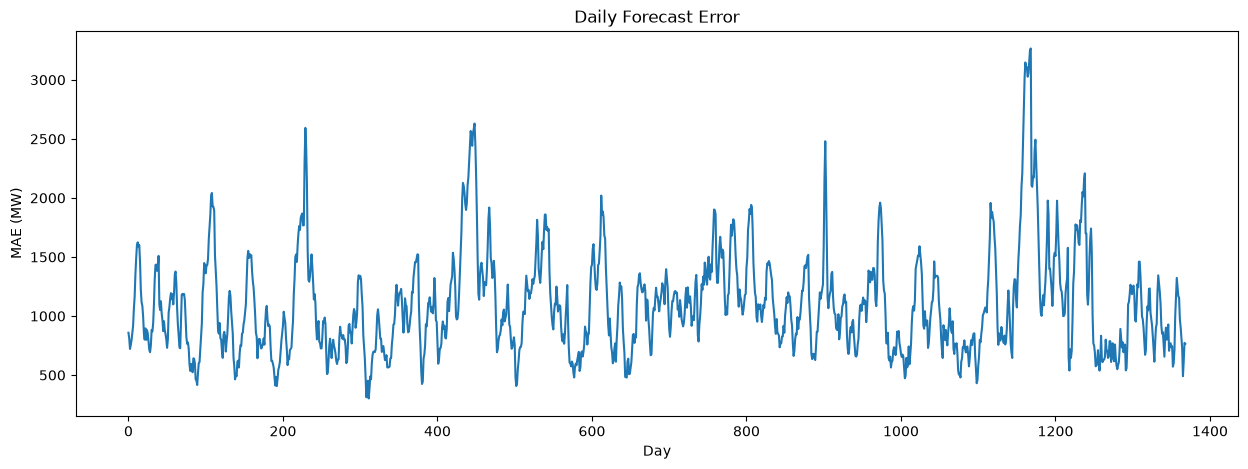

In [110]:
error = y_pred - y_true


validation_results = pd.DataFrame({
    "Actual": y_true,
    "Forecast": y_pred,
    "Error": error,
    "Absolute_Error": np.abs(error)
})


daily_error = (
    validation_results["Absolute_Error"]
    .groupby(
        np.arange(len(validation_results)) // 24
    )
    .mean()
)


plt.figure(figsize=(15, 5))

plt.plot(daily_error)

plt.title("Daily Forecast Error")
plt.xlabel("Day")
plt.ylabel("MAE (MW)")

plt.show()

In [111]:
peak_threshold = np.percentile(
    y_true,
    90
)

peak_mask = y_true >= peak_threshold


peak_mae = mean_absolute_error(
    y_true[peak_mask],
    y_pred[peak_mask]
)

peak_rmse = np.sqrt(
    mean_squared_error(
        y_true[peak_mask],
        y_pred[peak_mask]
    )
)

print("Peak Demand MAE :", peak_mae)
print("Peak Demand RMSE:", peak_rmse)

Peak Demand MAE : 1112.5432694579931
Peak Demand RMSE: 1527.951109690949


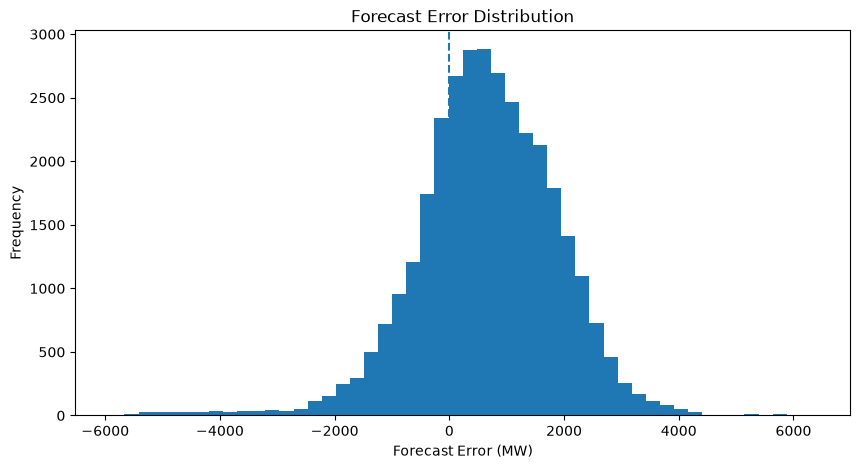

In [112]:
plt.figure(figsize=(10, 5))

plt.hist(
    error,
    bins=50
)

plt.axvline(
    0,
    linestyle="--"
)

plt.title("Forecast Error Distribution")
plt.xlabel("Forecast Error (MW)")
plt.ylabel("Frequency")

plt.show()

# 30 Days

In [113]:
test_size = int(len(df) * 0.20)

test_start = len(df) - test_size

X_test = X.iloc[test_start:]
y_test = y.iloc[test_start:]


validation_hours = 30 * 24   

val_start = test_start - validation_hours

X_val = X.iloc[val_start:test_start]
y_val = y.iloc[val_start:test_start]

X_train = X.iloc[:val_start]
y_train = y.iloc[:val_start]

print("X_train:", X_train.shape)
print("X_val  :", X_val.shape)
print("X_test :", X_test.shape)

print("\ny_train:", y_train.shape)
print("y_val  :", y_val.shape)
print("y_test :", y_test.shape)

X_train: (115304, 19)
X_val  : (720, 19)
X_test : (29006, 19)

y_train: (115304,)
y_val  : (720,)
y_test : (29006,)


In [115]:
from sklearn.preprocessing import StandardScaler

X_scaler = StandardScaler()

X_train_scaled = X_scaler.fit_transform(X_train)

X_val_scaled = X_scaler.transform(X_val)

X_test_scaled = X_scaler.transform(X_test)

y_scaler = StandardScaler()

y_train_scaled = y_scaler.fit_transform(
    y_train.values.reshape(-1, 1)
)

y_val_scaled = y_scaler.transform(
    y_val.values.reshape(-1, 1)
)

y_test_scaled = y_scaler.transform(
    y_test.values.reshape(-1, 1)
)

In [116]:
X_train_seq, y_train_seq = create_sequences(
    X_train_scaled,
    y_train_scaled,
    sequence_length,
    forecast_horizon
)

X_val_seq, y_val_seq = create_sequences(
    X_val_scaled,
    y_val_scaled,
    sequence_length,
    forecast_horizon
)

X_test_seq, y_test_seq = create_sequences(
    X_test_scaled,
    y_test_scaled,
    sequence_length,
    forecast_horizon
)

In [117]:
val_pred_scaled = final_model.predict(
    X_val_seq
)

val_pred = y_scaler.inverse_transform(
    val_pred_scaled.reshape(-1, 1)
).reshape(val_pred_scaled.shape)

y_val_original = y_scaler.inverse_transform(
    y_val_seq.reshape(-1, 1)
).reshape(y_val_seq.shape)

21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step


In [118]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

y_true = y_val_original.flatten()
y_pred = val_pred.flatten()

mae = mean_absolute_error(
    y_true,
    y_pred
)

mse = mean_squared_error(
    y_true,
    y_pred
)

rmse = np.sqrt(mse)

mape = np.mean(
    np.abs((y_true - y_pred) / y_true)
) * 100

r2 = r2_score(
    y_true,
    y_pred
)

bias = np.mean(
    y_pred - y_true
)

print("60 Validation Results")
print("------------------")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("MAPE:", mape)
print("R²  :", r2)
print("Bias:", bias)

60 Validation Results
------------------
MAE : 1134.3772355105611
MSE : 2083136.2216401396
RMSE: 1443.307389865423
MAPE: 4.227480912022442
R²  : 0.8797697782163472
Bias: 588.2752419086255


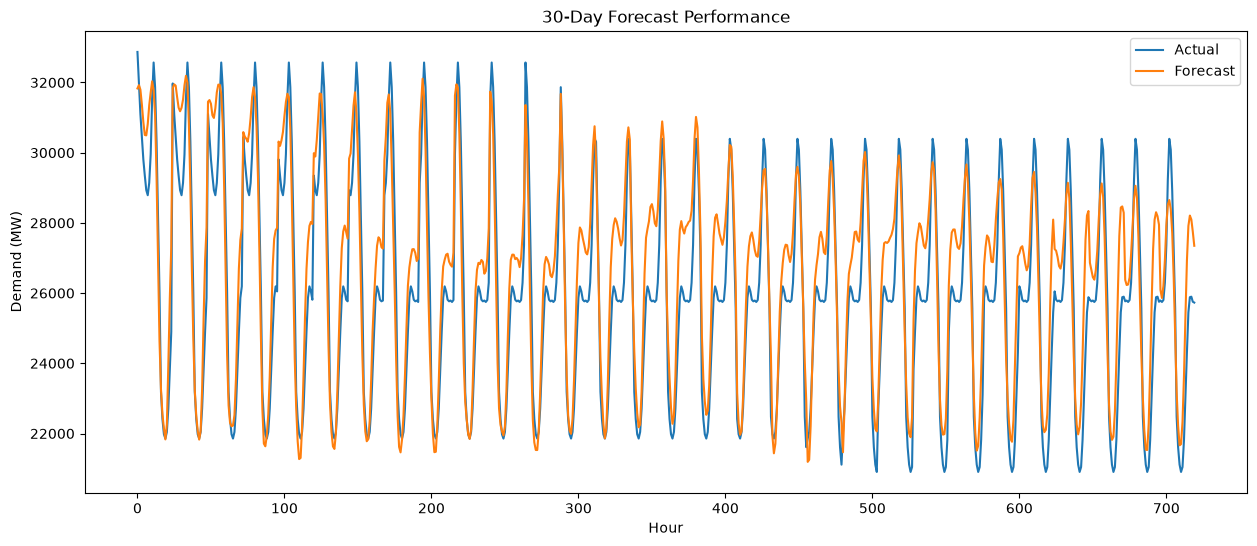

In [119]:
hours_30 = 30 * 24

plt.figure(figsize=(15, 6))

plt.plot(
    y_true[:hours_30],
    label="Actual"
)

plt.plot(
    y_pred[:hours_30],
    label="Forecast"
)

plt.title("30-Day Forecast Performance")
plt.xlabel("Hour")
plt.ylabel("Demand (MW)")
plt.legend()

plt.show()

In [121]:
peak_threshold = np.percentile(
    y_true,
    90
)

peak_mask = y_true >= peak_threshold


peak_mae = mean_absolute_error(
    y_true[peak_mask],
    y_pred[peak_mask]
)

peak_rmse = np.sqrt(
    mean_squared_error(
        y_true[peak_mask],
        y_pred[peak_mask]
    )
)

print("Peak Demand MAE :", peak_mae)
print("Peak Demand RMSE:", peak_rmse)

Peak Demand MAE : 1487.8301306418055
Peak Demand RMSE: 1976.9620240485235


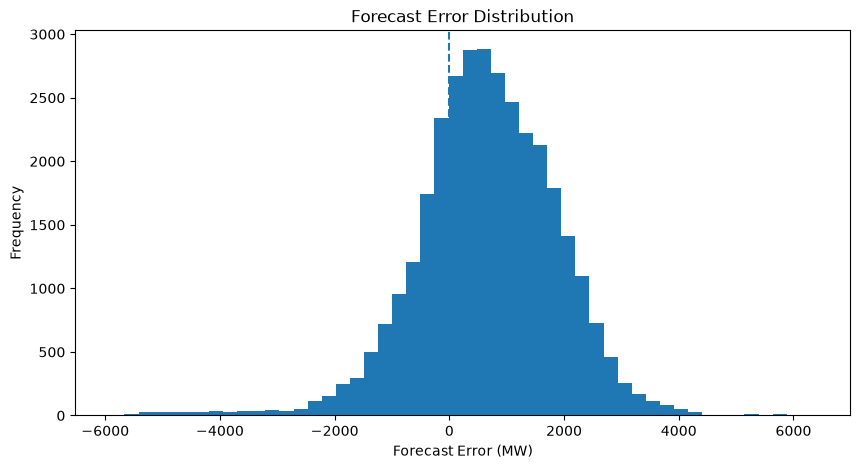

In [122]:
plt.figure(figsize=(10, 5))

plt.hist(
    error,
    bins=50
)

plt.axvline(
    0,
    linestyle="--"
)

plt.title("Forecast Error Distribution")
plt.xlabel("Forecast Error (MW)")
plt.ylabel("Frequency")

plt.show()

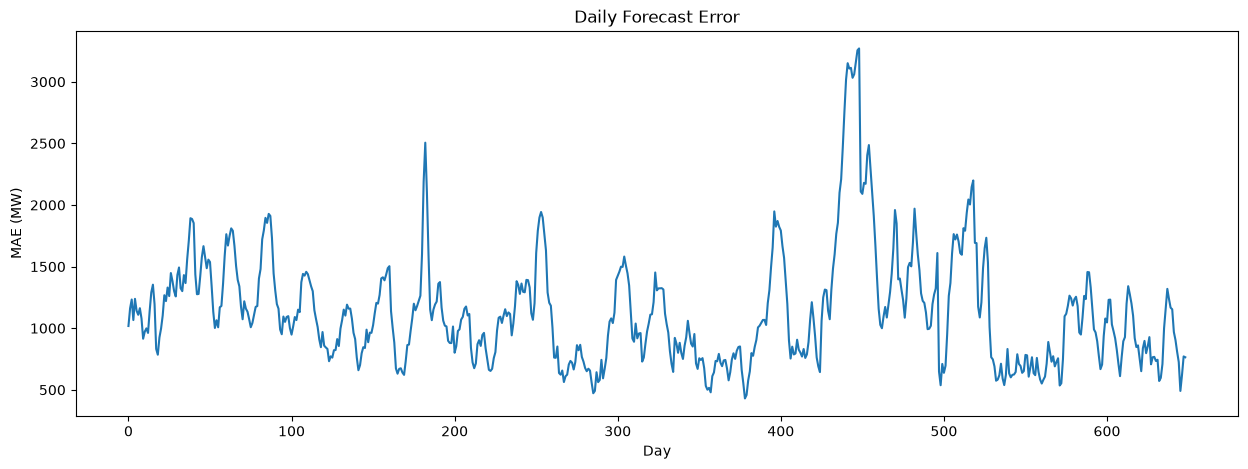

In [123]:
error = y_pred - y_true


validation_results = pd.DataFrame({
    "Actual": y_true,
    "Forecast": y_pred,
    "Error": error,
    "Absolute_Error": np.abs(error)
})


daily_error = (
    validation_results["Absolute_Error"]
    .groupby(
        np.arange(len(validation_results)) // 24
    )
    .mean()
)


plt.figure(figsize=(15, 5))

plt.plot(daily_error)

plt.title("Daily Forecast Error")
plt.xlabel("Day")
plt.ylabel("MAE (MW)")

plt.show()